In [1]:
import pysam, os, glob
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


In [2]:
hprc_sv_path = "/stornext/snfs4/next-gen/scratch/Yilei/projects/sv_methylation/hapmap_sv_benchmark/sv_benchmarking_collapsed_result.vcf"

In [3]:
hprc_sv = pysam.VariantFile(hprc_sv_path, 'r')
sample_list = ["HG002", "HG00438", "HG005", "HG02257", "HG02486", "HG02622"]

In [4]:
sv_df = pd.DataFrame(columns=["chr", "location", "id", "sv_len", ] + sample_list)

In [5]:
# Iterate through the records in the VCF file
for record in hprc_sv.fetch():
    df_record = {"chr": record.chrom, "location": record.pos, "id": record.id, "sv_len": record.info["SVLEN"]}
    for sample_name in sample_list:
        df_record.update({sample_name:record.samples[sample_name]['GT']})
        # print(f"{sample_name} Genotype: {record.samples[sample_name]['GT']}")
    sv_df.loc[len(sv_df)] = df_record

In [16]:
sv_df

,chr,location,id,sv_len,HG002,HG00438,HG005,HG02257,HG02486,HG02622
0,chr1,710579,HapMapBench.00000002,344,"(0, 0)","(1, 0)","(0, 0)","(1, 0)","(0, 0)","(0, 0)"
1,chr1,710579,HapMapBench.00000001,320,"(1, 1)","(0, 1)","(1, 1)","(0, 1)","(1, 1)","(1, 0)"
2,chr1,711958,HapMapBench.00000006,-90,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 1)"
3,chr1,714324,HapMapBench.00000007,-50,"(1, 1)","(1, 1)","(1, 1)","(1, 1)","(1, 1)","(0, 1)"
4,chr1,714355,HapMapBench.00000008,-97,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(1, 0)"
...,...,...,...,...,...,...,...,...,...,...
81449,chr9,138126765,HapMapBench.00057772,-59,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(1, 0)","(0, 0)"
81450,chr9,138126768,HapMapBench.00057773,122,"(0, 0)","(1, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
81451,chr9,138126945,HapMapBench.00057774,61,"(0, 0)","(0, 0)","(0, 0)","(1, 0)","(0, 0)","(0, 0)"
81452,chr9,138126949,HapMapBench.00057775,607,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(1, 0)"


In [17]:
def is_only_one_not_zero_zero(row):
    non_zero_count = sum(row[sample] !=(0, 0) for sample in sample_list)
    # print(non_zero_count )
    return non_zero_count == 1

In [18]:
filtered_df = sv_df[sv_df.apply(is_only_one_not_zero_zero, axis=1)]

In [19]:
# filtered_df[filtered_df['chr'] == 'chr1']['location'].diff().abs()
location_diff = filtered_df['location'].diff().abs()
distinct_sv_df = filtered_df[(location_diff > 1000) | (location_diff.isna())]
distinct_sv_df

,chr,location,id,sv_len,HG002,HG00438,HG005,HG02257,HG02486,HG02622
2,chr1,711958,HapMapBench.00000006,-90,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 1)"
4,chr1,714355,HapMapBench.00000008,-97,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(1, 0)"
5,chr1,724994,HapMapBench.00000009,-2184,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 1)"
6,chr1,727299,HapMapBench.00000010,97,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 1)"
7,chr1,744866,HapMapBench.00000011,50,"(0, 0)","(1, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
...,...,...,...,...,...,...,...,...,...,...
81436,chr9,138001301,HapMapBench.00057756,56,"(0, 0)","(0, 1)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
81437,chr9,138017897,HapMapBench.00057761,-1295,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 1)","(0, 0)"
81443,chr9,138053582,HapMapBench.00057764,-58,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(1, 0)"
81444,chr9,138081483,HapMapBench.00057765,-6085,"(0, 0)","(0, 1)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"


In [20]:
HG00438_vcf = pysam.VariantFile("hprc_data/HG00438.sorted_germline.vcf.gz")
HG005_vcf = pysam.VariantFile("hprc_data/HG005_germline.vcf.gz")
HG002_vcf = pysam.VariantFile("hprc_data/HG002_germline.vcf.gz")
HG02257_vcf = pysam.VariantFile("hprc_data/HG02257.sorted_germline.vcf.gz")
HG02486_vcf = pysam.VariantFile("hprc_data/HG02486.sorted_germline.vcf.gz")
HG02622_vcf = pysam.VariantFile("hprc_data/HG02622.sorted_germline.vcf.gz")

In [21]:
def read_vcf_to_df(vcf_file):
    # Iterate through the records in the VCF file
    sv_df = pd.DataFrame(columns=["chr", "location", "id", "sv_len", "supporting_reads", "std"])
    for record in vcf_file.fetch():
        # print(record)
        if (record.info["SVTYPE"] == "INS") or (record.info["SVTYPE"] == "DEL"):
            df_record = {"chr": record.chrom, "location": record.pos, "id": record.id, "sv_len": record.info["SVLEN"], "supporting_reads":record.info.get("RNAMES", "NA")}
            # for sample_name in sample_list:
            # df_record.update({sample_name:record.samples[sample_name]['GT']})

        sv_df.loc[len(sv_df)] = df_record
    return sv_df

In [22]:
HG005_sv_df = read_vcf_to_df(HG005_vcf)
HG00438_sv_df = read_vcf_to_df(HG00438_vcf)
HG002_sv_df = read_vcf_to_df(HG002_vcf)
HG02257_sv_df = read_vcf_to_df(HG02257_vcf)
HG02486_sv_df = read_vcf_to_df(HG02486_vcf)
HG02622_sv_df = read_vcf_to_df(HG02622_vcf)

In [23]:
def map_values(value):
    if value == (1, 1):
        return 1
    elif value in [(0, 1), (1, 0)]:
        return 0.5
    else:
        return 0

In [24]:
search_threshold = 1000
with open("hapmap_sv_benchmark/only_one_sample_del_1000_renewed.bed", "w") as only_one_sample_ins:
    for index, i in distinct_sv_df[(distinct_sv_df['sv_len'] < 0)].iterrows():
        bed_str = f"{i.chr}\t{i.location-search_threshold}\t{i.location+search_threshold-i.sv_len}\t{i.id}\n"
        only_one_sample_ins.writelines(bed_str)

# search_threshold = 100
# with open("hapmap_sv_benchmark/only_one_sample_del_100.bed", "w") as only_one_sample_ins:
#     for index, i in distinct_sv_df[(distinct_sv_df['sv_len'] < 0)].iterrows():
#         bed_str = f"{i.chr}\t{i.location-search_threshold}\t{i.location+search_threshold}\t{i.id}\n"
#         only_one_sample_ins.writelines(bed_str)
#         # print(i)

In [25]:
def calculate_averages(df, samples):
    averages = {}
    for sample in samples:
        # Extract columns where the sample is involved
        relevant_columns = [col for col in df.columns if sample in col]
        # print(relevant_columns)
        # break
        # Calculate the average score for the sample
        sample_averages = df[relevant_columns].mean(axis=1)
        
        # Store the result
        averages[sample] = sample_averages
    return pd.DataFrame(averages)

In [26]:
with open("hapmap_sv_filtering/filtered_sv_hetero.list", "w") as filtered_sv_hetro:
    for i in list(distinct_sv_df.id):
        filtered_sv_hetro.writelines(f"{i}\n")

/space1/tmp/slurm.674210/ipykernel_3465244/2746480446.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sv_heatmap_df = sorted_distinct_sv_df[sample_list].applymap(map_values)


<Axes: ylabel='id'>

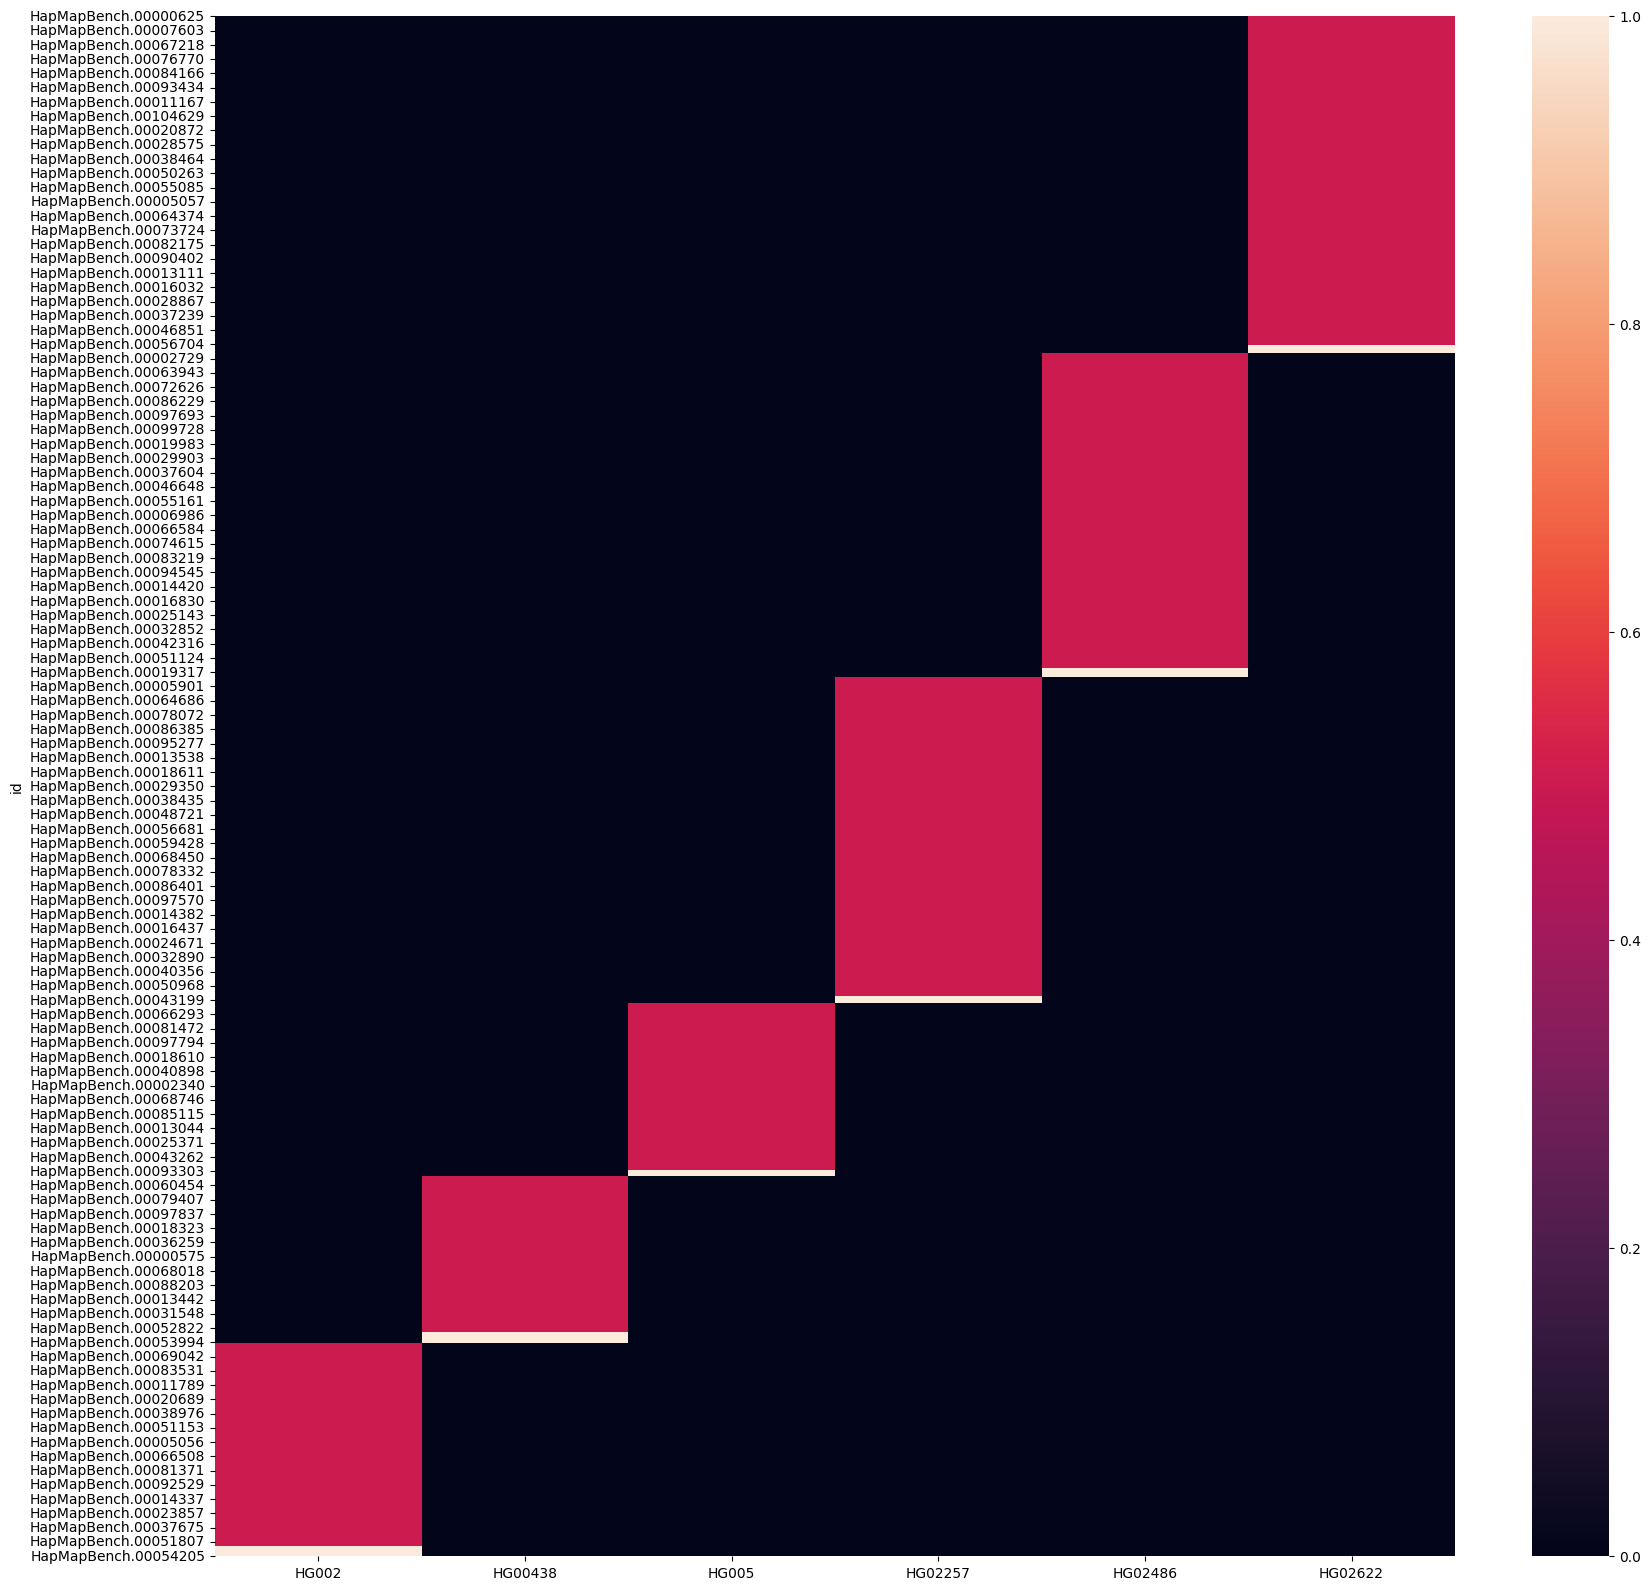

In [27]:
sorted_distinct_sv_df = distinct_sv_df[(distinct_sv_df['sv_len'] > 250)].sort_values(sample_list)
sorted_distinct_sv_df = sorted_distinct_sv_df.set_index('id')
sorted_distinct_sv_df_homo = sorted_distinct_sv_df[sorted_distinct_sv_df.isin([(1,1)]).any(axis=1)]
sv_heatmap_df = sorted_distinct_sv_df[sample_list].applymap(map_values)
plt.figure(figsize=(20, 20))
sns.heatmap(sv_heatmap_df)
# # sv_heatmap_df

In [28]:
def plot_sv_methylation_relationship(bed_file_folder, sv_df):
    bed_file_1000 = glob.glob(bed_file_folder + "*.bed")
    print(bed_file_1000)
    bed_df_list = []
    data_dict = {}
    for bed_file in bed_file_1000:
        # Read the file into a DataFrame
        bed_file_df = pd.read_csv(bed_file, sep='\t', header=None)
        
        # Extract the 4th and 5th columns
        bed_file_df = bed_file_df[[3, 4]]
        
        # Set the 4th column as the index
        bed_file_df.set_index(3, inplace=True)
        
        # Use the filename (without extension) as the column name
        file_name = bed_file.split("/")[-1].split(".")[0]
        data_dict[file_name] = bed_file_df[4]
    # print(data_dict)
    result_df = pd.DataFrame(data_dict)
    sorted_df = result_df.reindex(sv_df.index).reset_index()
    sorted_df = sorted_df.set_index('id')
    comparison_average = calculate_averages(sorted_df, sample_list)
    comparison_average[comparison_average > 25] = -1
    comparison_average = comparison_average.dropna()

    plt.figure(figsize=(20, 20))
    sns.heatmap(comparison_average)
    return comparison_average

['hprc_modkit/ins_dmr_100.bed/HG00438_HG02622.bed', 'hprc_modkit/ins_dmr_100.bed/HG002_HG02257.bed', 'hprc_modkit/ins_dmr_100.bed/HG00438_HG02486.bed', 'hprc_modkit/ins_dmr_100.bed/HG005_HG00438.bed', 'hprc_modkit/ins_dmr_100.bed/HG005_HG02486.bed', 'hprc_modkit/ins_dmr_100.bed/HG005_HG02622.bed', 'hprc_modkit/ins_dmr_100.bed/HG002_HG02486.bed', 'hprc_modkit/ins_dmr_100.bed/HG00438_HG02257.bed', 'hprc_modkit/ins_dmr_100.bed/HG002_HG02622.bed', 'hprc_modkit/ins_dmr_100.bed/HG002_HG00438.bed', 'hprc_modkit/ins_dmr_100.bed/HG02486_HG02622.bed', 'hprc_modkit/ins_dmr_100.bed/HG002_HG005.bed', 'hprc_modkit/ins_dmr_100.bed/HG005_HG02257.bed', 'hprc_modkit/ins_dmr_100.bed/HG02257_HG02486.bed', 'hprc_modkit/ins_dmr_100.bed/HG02257_HG02622.bed']


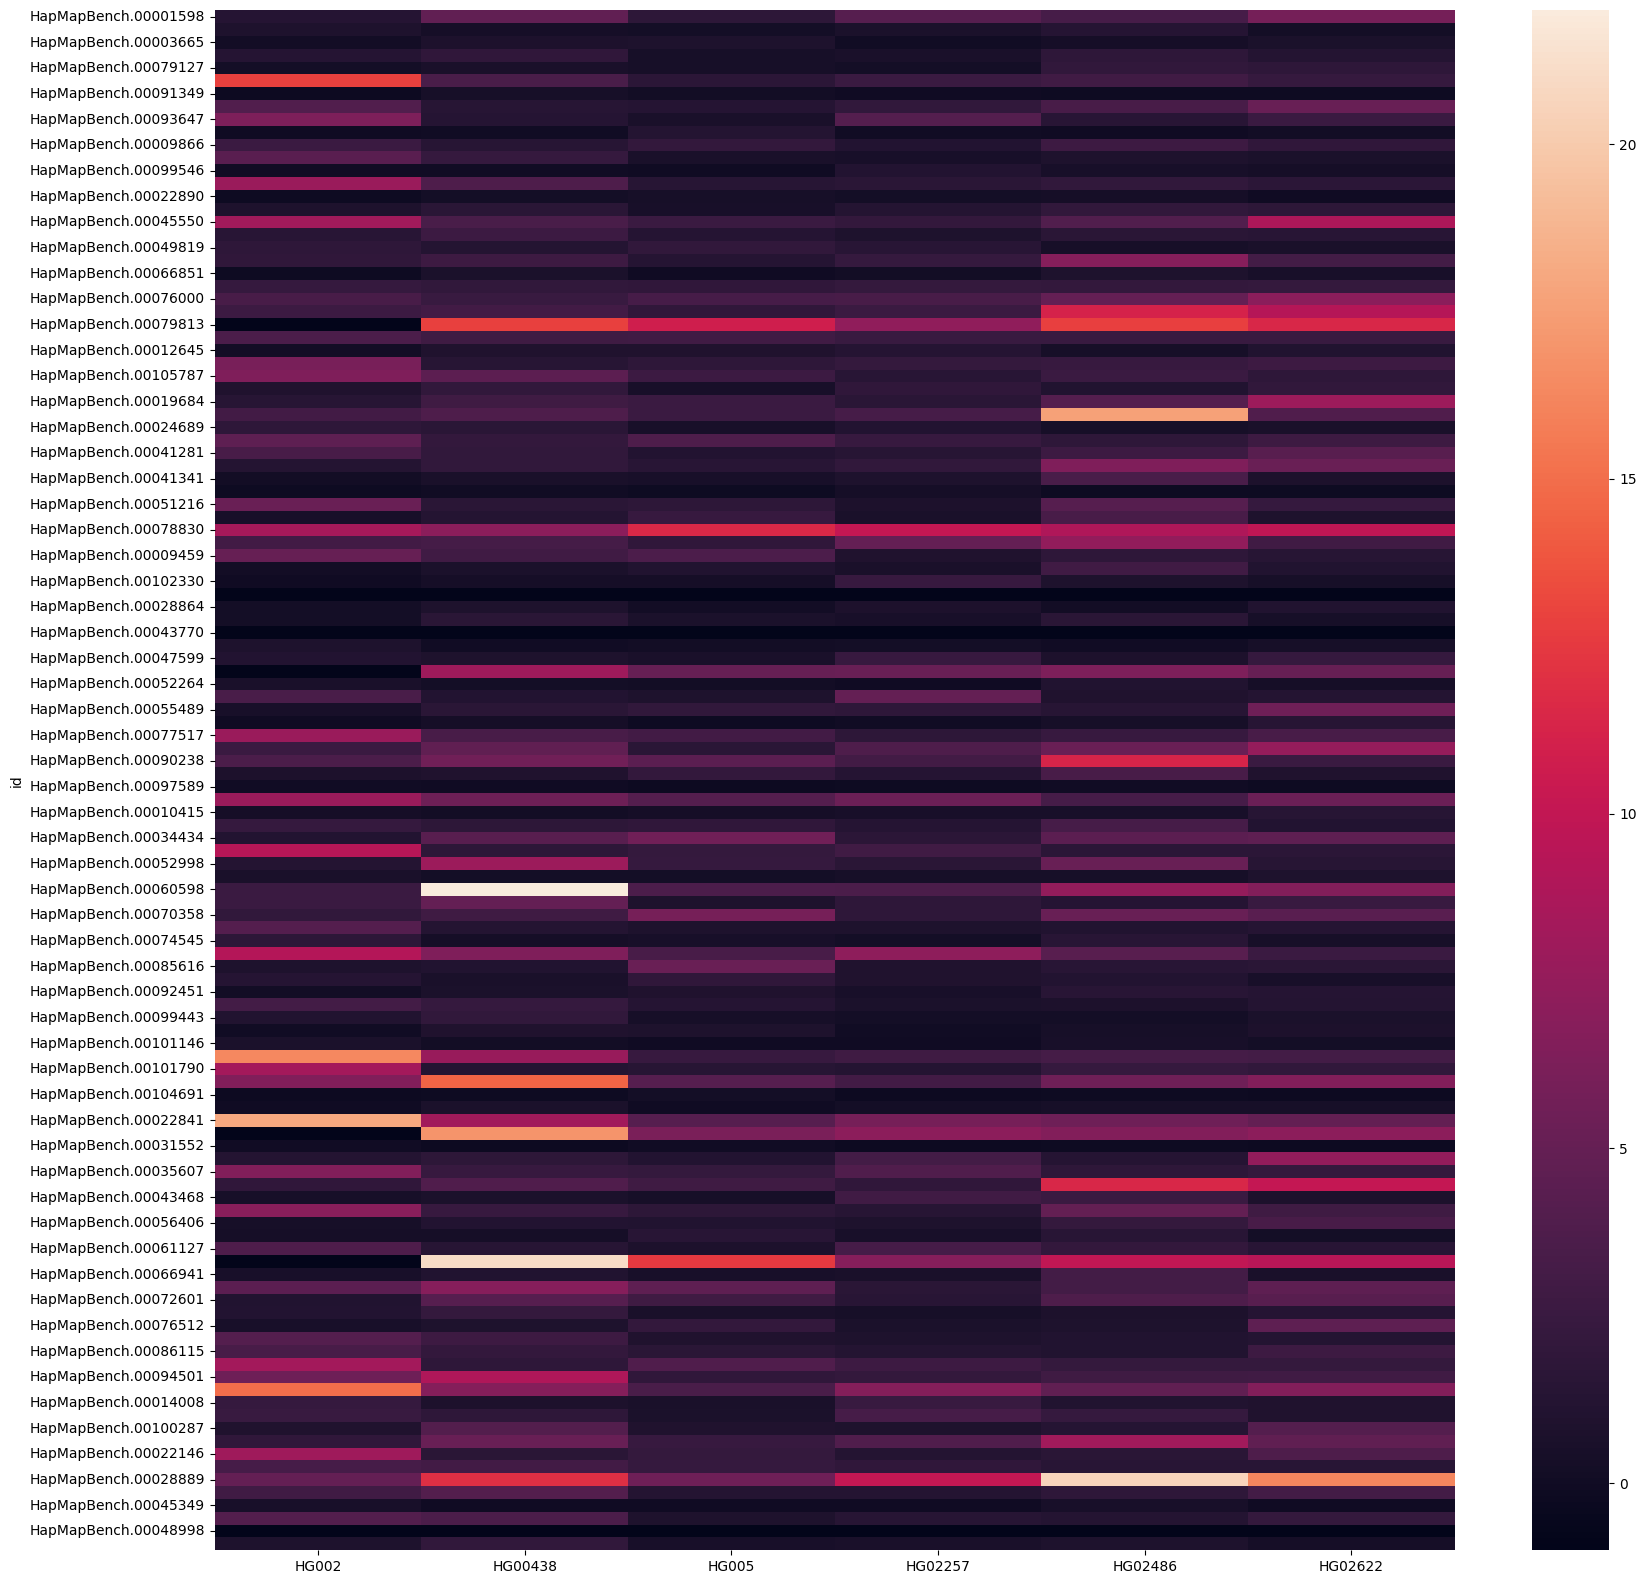

In [29]:
comparison_average = plot_sv_methylation_relationship("hprc_modkit/ins_dmr_100.bed/", sorted_distinct_sv_df_homo)

<Axes: ylabel='id'>

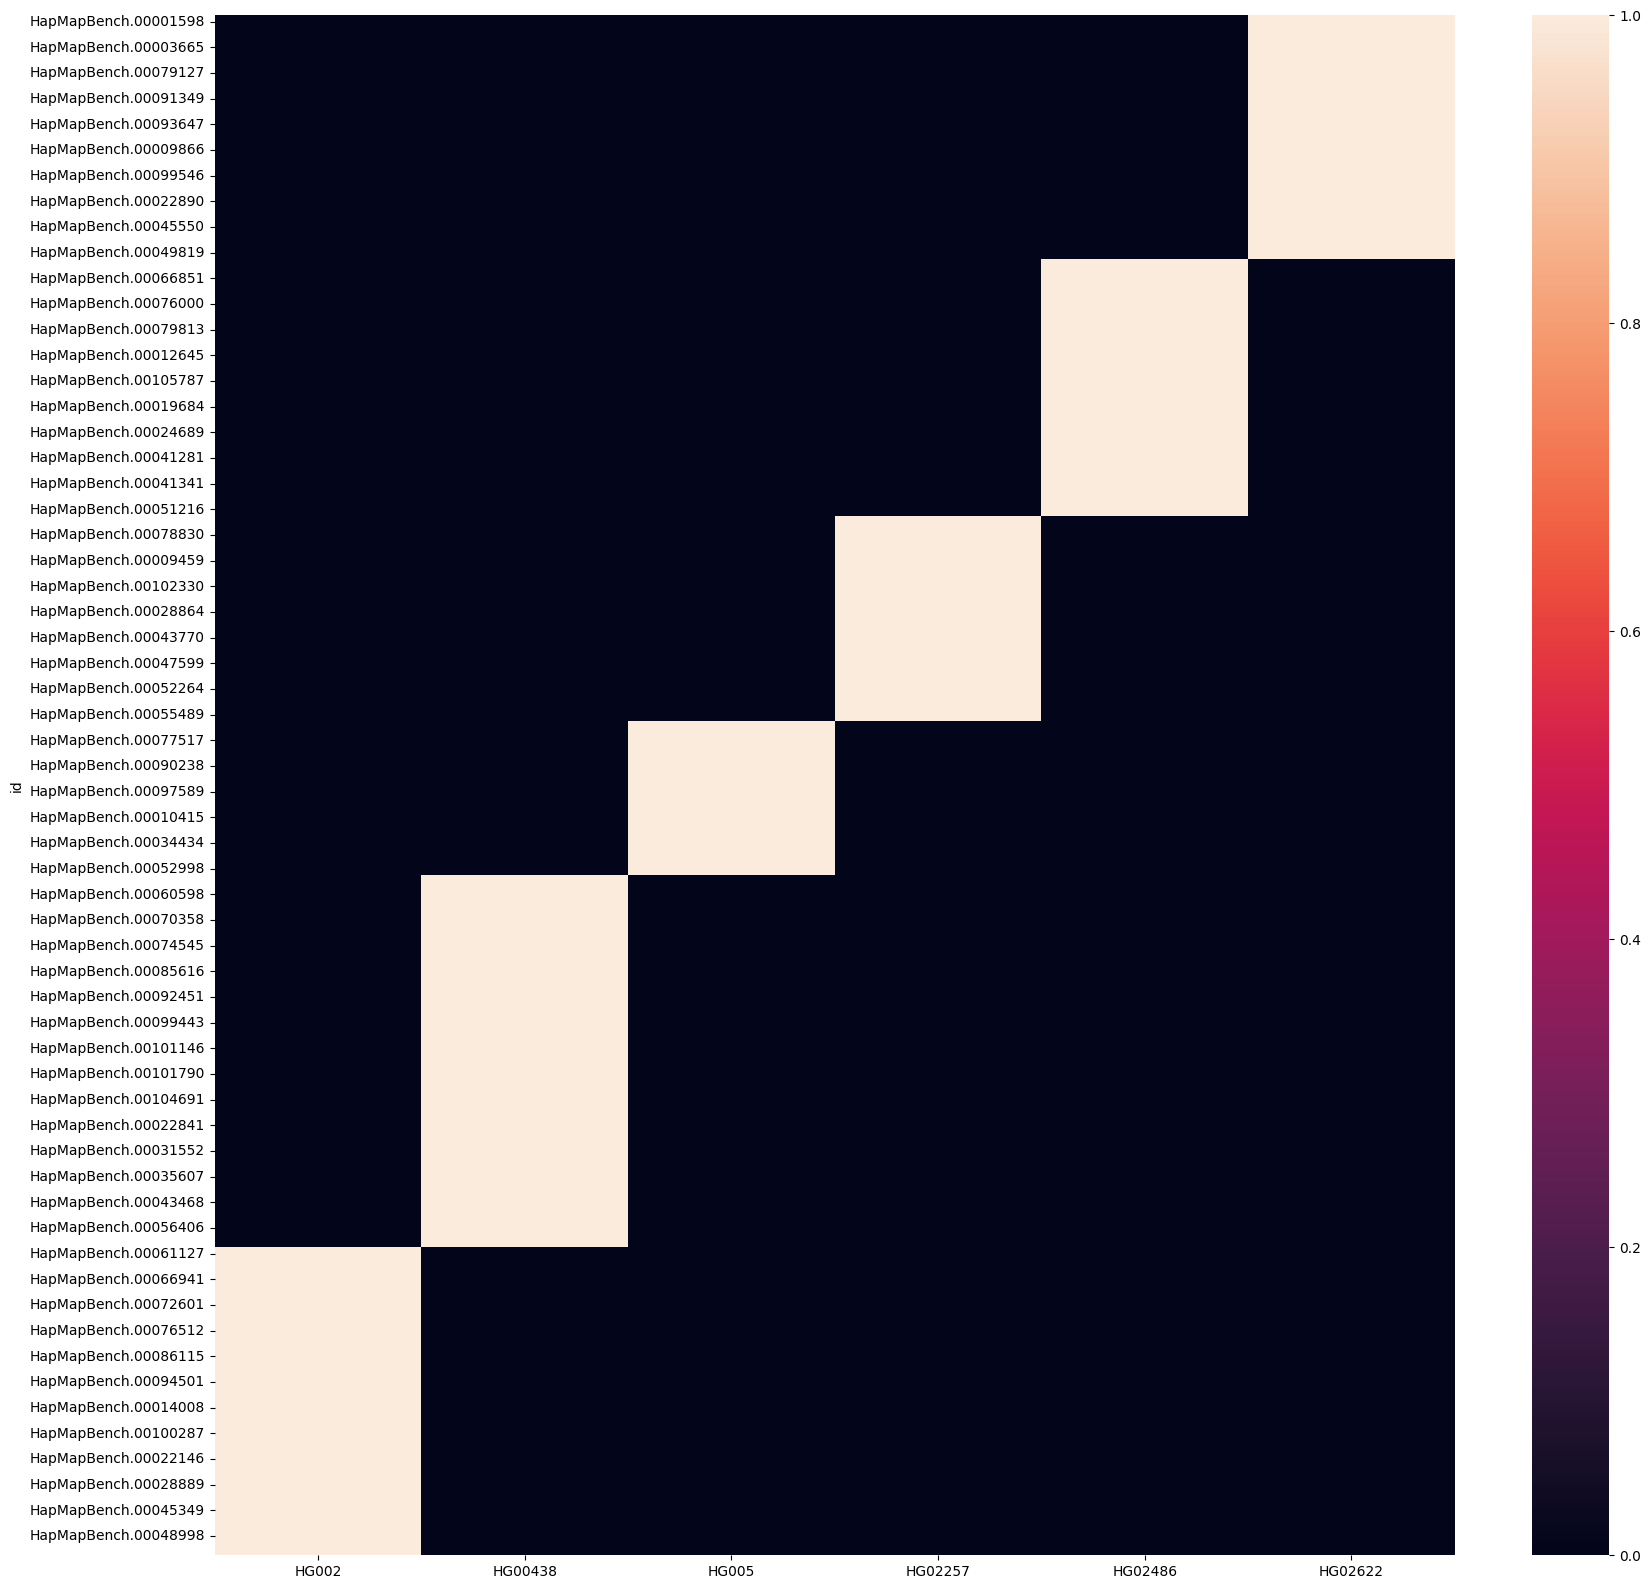

In [30]:
plt.figure(figsize=(20, 20))
sns.heatmap(sv_heatmap_df.reindex(comparison_average.index))

In [31]:
filtered_mosaic_sv = pysam.VariantFile("hapmap_sv_filtering/sv_benchmarking_collapsed_filtered_hetero_mosiac_bench/tp-comp.vcf.gz")

In [32]:
filtered_mosaic_sv_df = read_vcf_to_df(filtered_mosaic_sv)

In [33]:
filtered_mosaic_sv_df
filtered_mosaic_sv_df_filtered_200bps = filtered_mosaic_sv_df[(filtered_mosaic_sv_df.sv_len >= 200) | (filtered_mosaic_sv_df.sv_len <= -200) & (filtered_mosaic_sv_df.supporting_reads.apply(len) > 10)]
filtered_mosaic_sv_df_filtered_200bps

,chr,location,id,sv_len,supporting_reads
1,chr1,904657,Sniffles2.INS.52S0,355,"(fbce6b2f-67ca-4c2f-a66f-0d6e1ae2930e, 54d1278..."
3,chr1,1076228,Sniffles2.DEL.21D5S0,-538,"(bc20e096-4d3c-4f83-9335-46084db73a87, 7403017..."
5,chr1,1175869,Sniffles2.INS.78S0,272,"(0b25d640-93a7-4391-810d-deae99c50f83, 9d195e7..."
6,chr1,1184758,Sniffles2.INS.7DS0,753,"(9d195e7c-a01e-45a0-a1e1-36de3e981f07, 4fbde2d..."
10,chr1,1605517,Sniffles2.INS.A8S0,275,"(b8abd015-a24b-4572-962e-f02cfdcc6179, 53844ba..."
...,...,...,...,...,...
5009,chr22,48736171,Sniffles2.INS.837S15,683,"(0bf32337-edb7-4a4e-bb18-5e52c619428b, 3b748dd..."
5018,chr22,49407421,Sniffles2.INS.87AS15,204,"(a8e064b0-1013-41f5-9d86-546dadc1e6e4, eb5b941..."
5020,chr22,49494317,Sniffles2.INS.884S15,1060,"(07d7be2d-52ea-4284-9c0e-a0eea2415b3e, ccadf09..."
5027,chr22,50009895,Sniffles2.INS.8B2S15,759,"(99bfa973-5d40-4ae6-bc25-deb160836785, c994022..."


In [34]:
search_threshold = 1000
with open("hapmap_sv_filtering/sv_related_1000bps.bed", "w") as only_one_sample_ins:
    for index, i in filtered_mosaic_sv_df.iterrows():
        if i.sv_len < 0:
            bed_str = f"{i.chr}\t{i.location-search_threshold}\t{i.location+search_threshold-i.sv_len}\t{i.id}\t.\t.\n"
        elif i.sv_len > 0:
            bed_str = f"{i.chr}\t{i.location-search_threshold}\t{i.location+search_threshold}\t{i.id}\t.\t.\n"
        only_one_sample_ins.writelines(bed_str)

In [35]:
search_threshold = 1000
with open("hapmap_sv_filtering/filtered_mosaic_sv_df_filtered_200bps_1000bps.bed", "w") as only_one_sample_ins:
    for index, i in filtered_mosaic_sv_df_filtered_200bps.iterrows():
        if i.sv_len < 0:
            bed_str = f"{i.chr}\t{i.location-search_threshold}\t{i.location+search_threshold-i.sv_len}\t{i.id}\t.\t.\n"
        elif i.sv_len > 0:
            bed_str = f"{i.chr}\t{i.location-search_threshold}\t{i.location+search_threshold}\t{i.id}\t.\t.\n"
        only_one_sample_ins.writelines(bed_str)

modkit extract -t 20 -q 100000 --reference ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa --read-calls-path ./ --cpg --include-bed sv_related_1000bps.bed --allow-non-primary ../hapmap_data/hapmap_smaht_ont.bam ./

samtools view -b@ 40 -L sv_related_1000bps.bed ../hapmap_data/hapmap_smaht_ont.bam | modkit extract -t 40 --allow-non-primary --log-filepath ./modkit_extract.log  --filter-threshold 0.9 --read-calls-path sv_related_read_calls.csv stdin sv_related.csv

In [36]:
per_read_methylation = pd.read_csv("./hapmap_sv_filtering/sv_filtered_200bps_1000bps/per_chromosome/filtered_mosaic_sv_df_filtered_200bps_1000bps_chr1_read_calls.csv", sep="\t")

In [48]:
dropping_columns = ["fw_soft_clipped_start", "fw_soft_clipped_end", "read_length", "mod_strand", "ref_strand", "ref_mod_strand", "base_qual", "ref_kmer", "query_kmer", "canonical_base", "modified_primary_base", "within_alignment", ]
per_read_methylation = per_read_methylation.drop(columns=dropping_columns)

In [49]:
filtered_mosaic_sv_df_filtered_200bps_chr1 = filtered_mosaic_sv_df_filtered_200bps[filtered_mosaic_sv_df_filtered_200bps.chr == 'chr1']

In [59]:
filtered_mosaic_sv_df_filtered_200bps_chr1[filtered_mosaic_sv_df_filtered_200bps_chr1.supporting_reads.apply(len)>5].to_csv("hapmap_sv_filtering/sv_filtered_200bps_1000bps/filtered_sv_location.csv")

In [57]:
filtered_mosaic_sv_df_filtered_200bps_chr1.loc[6].supporting_reads

('9d195e7c-a01e-45a0-a1e1-36de3e981f07',
 '4fbde2da-fbae-4b6d-822a-b8e5f24ad7dc',
 '0f0b7bae-9d29-4f5c-8e95-d1df93bda8b6',
 '8b28c27a-a6c5-43c8-89f3-d73c00f55382',
 '7f27266b-4545-4789-9e87-48e543fcb6ec',
 'c1b0226e-56c8-48ed-a899-d9a380f7c2a1',
 '0b25d640-93a7-4391-810d-deae99c50f83',
 '6ae832ad-b32d-512f-804c-103eaaac2014')

In [51]:
supporting_reads = filtered_mosaic_sv_df_filtered_200bps_chr1.iloc[0].supporting_reads

In [52]:
per_read_methylation[per_read_methylation.read_id.isin(supporting_reads)].to_csv("hapmap_sv_filtering/first_sv_check.csv")

In [53]:
supporting_reads

('fbce6b2f-67ca-4c2f-a66f-0d6e1ae2930e',
 '54d12782-9633-4a82-a910-54d0d0d87622',
 '8ab9dbc1-9883-48dd-bc0e-7acf5af34d81',
 'c4412d30-0c4e-4423-9e94-3b94d4257382',
 'c1db2fbc-aa2a-4e3a-95cb-42c22a381f3c',
 '4dd7e466-bae9-4e67-b9e2-efa29d444456',
 'dd788444-30f1-4445-a988-a0d9b5123c11')